In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jieba
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from pyecharts.charts import WordCloud
from pyecharts import options as opts

# 设置 seaborn 风格
sns.set_style('whitegrid')

# 读取数据（使用 gb18030 编码）
df = pd.read_csv('huoguo.csv', encoding='gb18030')
print("数据读取成功，共", len(df), "条记录")
df.head()

数据读取成功，共 749 条记录


,name,url,star,comment,avg_price,taste,environment,services,recommend
0,蜀城巷子老成都火锅(宜山路店),http://www.dianping.com/shop/110269910,准五星商户,545,122,8.6,8.4,8.5,"蜀城嫩鲜牛肉,毛肚,鸭血"
1,旬野菜日本料理和牛寿喜锅专门店(浦东店),http://www.dianping.com/shop/98281287,五星商户,602,313,8.8,9.1,9.0,"安格斯牛肉寿喜锅,刺身拼盘,澳洲和牛寿喜烧"
2,小肥羊(光启城时尚购物中心店),http://www.dianping.com/shop/72351070,准五星商户,4308,1,9.0,8.9,8.9,"特色羔羊肉,鸳鸯锅,招牌豪气羊肉串"
3,薪火重庆本味火锅,http://www.dianping.com/shop/114858370,准五星商户,128,12,8.4,8.7,8.9,"特色鲜鸭血,豚骨鸳鸯锅,现杀牛蛙"
4,蜀大侠(江宁路店),http://www.dianping.com/shop/98763397,五星商户,1529,133,9.0,9.0,8.9,"贵妃牛肉,大侠水牛毛肚,冰川鹅肠"


In [3]:
# 1.  删除缺失值
df.dropna(inplace=True)
print("删除缺失值后:", len(df), "条记录")

# 2. 修正异常价格（价格为1的修正为111）
df.loc[df['avg_price'] == 1, 'avg_price'] = 111

# 3. 星级转数值
star_map = {
    '五星商户': 5,
    '准五星商户': 4.5,
    '四星商户': 4,
    '准四星商户': 3.5
}
df['star_num'] = df['star'].map(star_map)

# 4. 创建英文星级标签（用于图表）
star_en_map = {
    '五星商户': '5-star',
    '准五星商户': '4.5-star',
    '四星商户': '4-star',
    '准四星商户': '3.5-star'
}
df['star_en'] = df['star'].map(star_en_map)

# 5. 排序展示
print("按价格排序 Top 5:")
print(df.sort_values('avg_price', ascending=False)[['name', 'avg_price']].head())
print("\n按评论数排序 Top 5:")
print(df.sort_values('comment', ascending=False)[['name', 'comment']].head())

删除缺失值后: 749 条记录
按价格排序 Top 5:
               name  avg_price
452    季悦火锅(虹桥迎宾馆店)       1073
217      洋房火锅(岳阳路店)       1058
49        季悦火锅(锦江店)       1007
104      洋房火锅(新天地店)        977
483  辉哥海鲜火锅(洛克外滩源店)        962

按评论数排序 Top 5:
                  name  comment
122  上上谦串串香火锅(新梅联合广场店)    41585
152   上上谦串串香火锅(虹口龙之梦店)    35468
89    哥老官重庆美蛙鱼头(人民广场店)    30514
80     哥老官重庆美蛙鱼头(日月光店)    30234
671     三人行骨头王火锅(徐汇总店)    27295


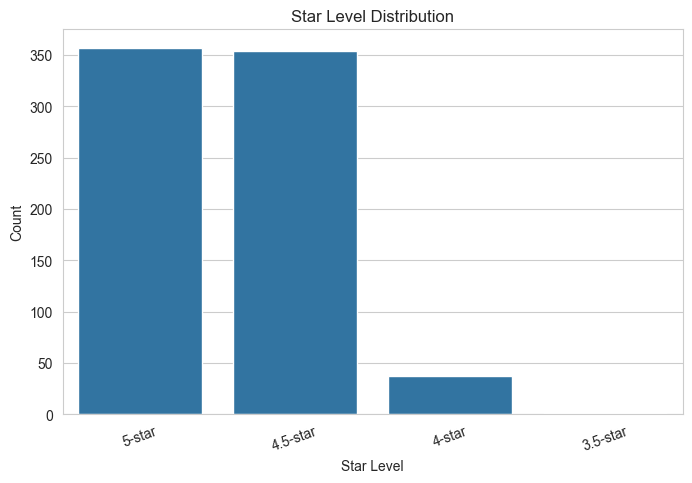

In [4]:
#星级分布柱状图
plt.figure(figsize=(8, 5))
sns.countplot(x='star_en', data=df, order=['5-star', '4.5-star', '4-star', '3.5-star'])
plt.title('Star Level Distribution')
plt.xlabel('Star Level')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()

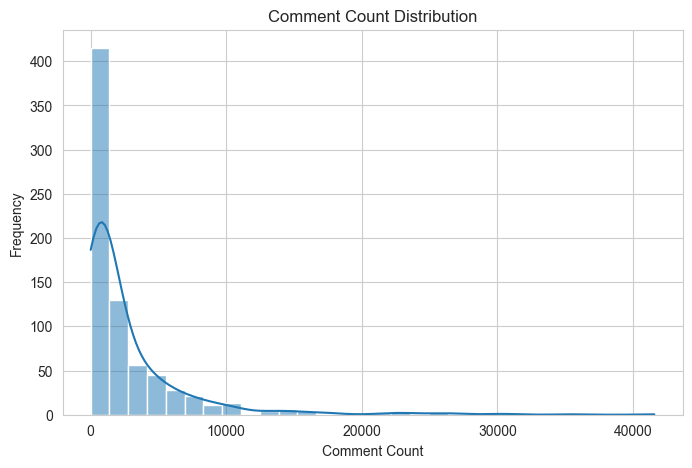

In [5]:
#评论数分布直方图
plt.figure(figsize=(8, 5))
sns.histplot(df['comment'], bins=30, kde=True)
plt.title('Comment Count Distribution')
plt.xlabel('Comment Count')
plt.ylabel('Frequency')
plt.show()

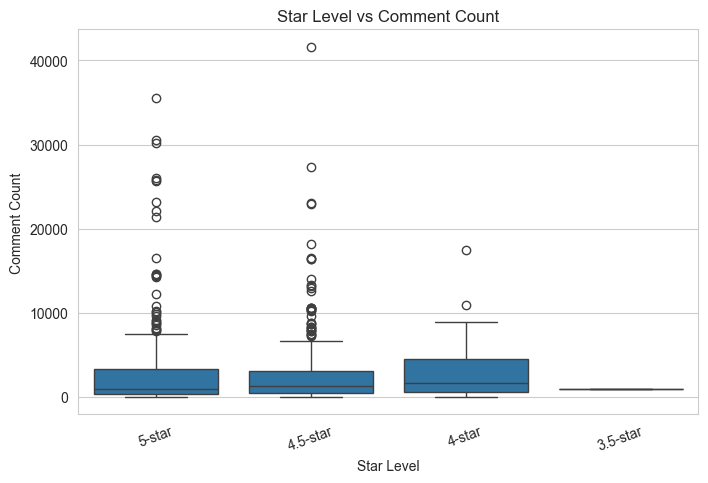

In [6]:
#星级与评论数关系箱线图
plt.figure(figsize=(8, 5))
sns.boxplot(x='star_en', y='comment', data=df, order=['5-star', '4.5-star', '4-star', '3.5-star'])
plt.title('Star Level vs Comment Count')
plt.xlabel('Star Level')
plt.ylabel('Comment Count')
plt.xticks(rotation=20)
plt.show()

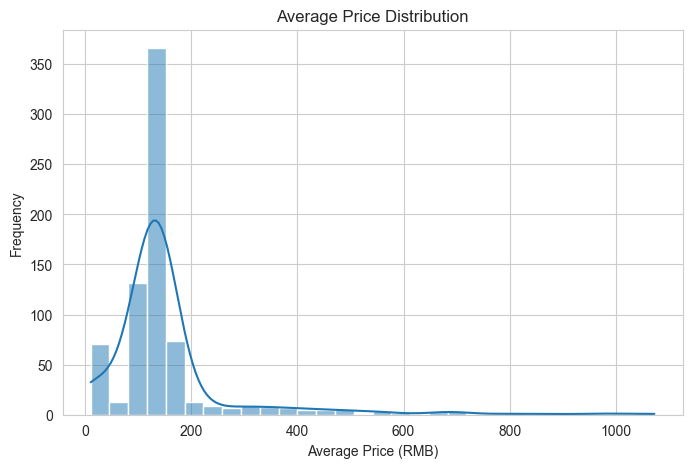

In [7]:
#人均价格分布图
plt.figure(figsize=(8, 5))
sns.histplot(df['avg_price'], bins=30, kde=True)
plt.title('Average Price Distribution')
plt.xlabel('Average Price (RMB)')
plt.ylabel('Frequency')
plt.show()

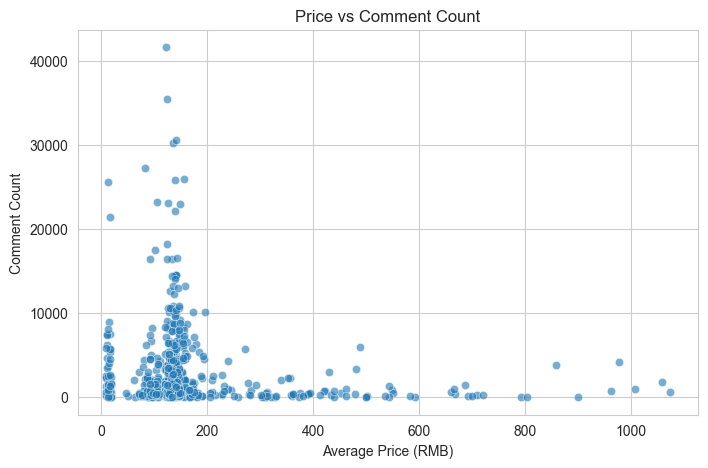

In [8]:
#价格与评论数散点图
plt.figure(figsize=(8, 5))
sns.scatterplot(x='avg_price', y='comment', data=df, alpha=0.6)
plt.title('Price vs Comment Count')
plt.xlabel('Average Price (RMB)')
plt.ylabel('Comment Count')
plt.show()

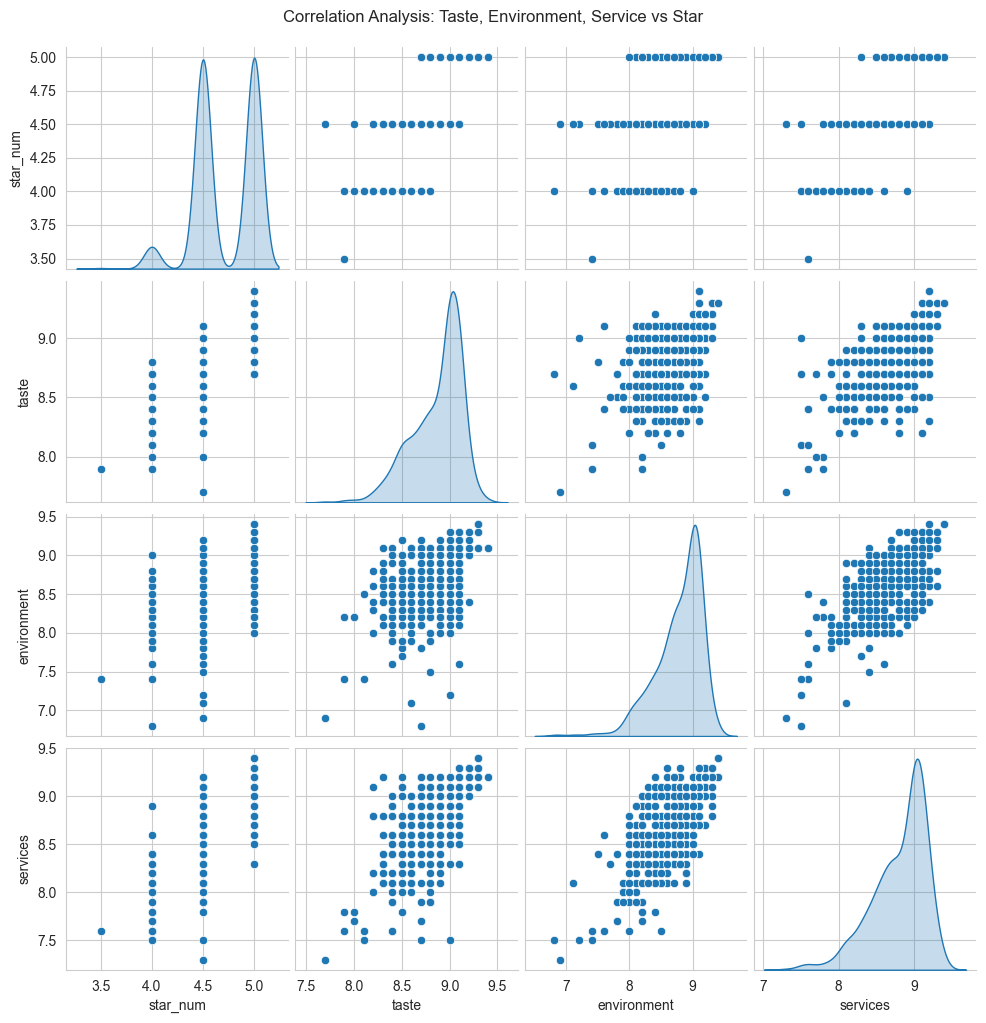

In [9]:
#口味、环境、服务与星级的相关性分析（pairplot）
cols = ['star_num', 'taste', 'environment', 'services']
sns.pairplot(df[cols], diag_kind='kde')
plt.suptitle('Correlation Analysis: Taste, Environment, Service vs Star', y=1.02)
plt.show()

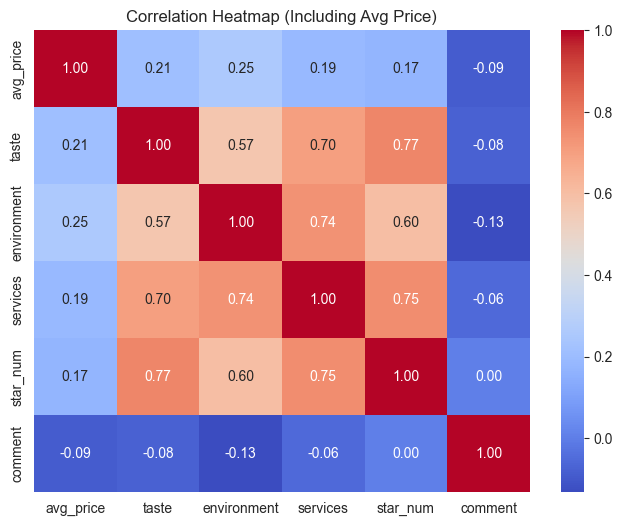

In [10]:
#热力图（人均价格与其他指标的相关性）
plt.figure(figsize=(8, 6))
corr = df[['avg_price', 'taste', 'environment', 'services', 'star_num', 'comment']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Including Avg Price)')
plt.show()

In [11]:
#生成词云
from pyecharts.charts import WordCloud
from pyecharts import options as opts
from collections import Counter
import jieba

all_recommend = ' '.join(df['recommend'].dropna().astype(str))
words = jieba.cut(all_recommend, cut_all=False)
stopwords = ['的', '了', '在', '是', '我', '有', '和', '就', '不', '人', '都', '一', '个', '上', '也', '很', '至', '至多', '左右']
word_list = [w for w in words if len(w) > 1 and w not in stopwords]
word_freq = Counter(word_list).most_common(100)

wc = WordCloud()
wc.add(series_name="Recommend Dishes", data_pair=word_freq, word_size_range=[12, 60])
wc.set_global_opts(title_opts=opts.TitleOpts(title="Popular Recommended Dishes"))
wc.render("hotpot_wordcloud.html")

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Rui\AppData\Local\Temp\jieba.cache
Loading model cost 0.963 seconds.
Prefix dict has been built successfully.


'C:\\Users\\Rui\\hotpot_wordcloud.html'

Clustering Centers (Original Scale):
   star_num     taste  environment  services
0  4.997199  9.059944     8.996078  9.053782
1  4.339130  8.495652     8.206087  8.200870
2  4.500000  8.781588     8.739350  8.733213


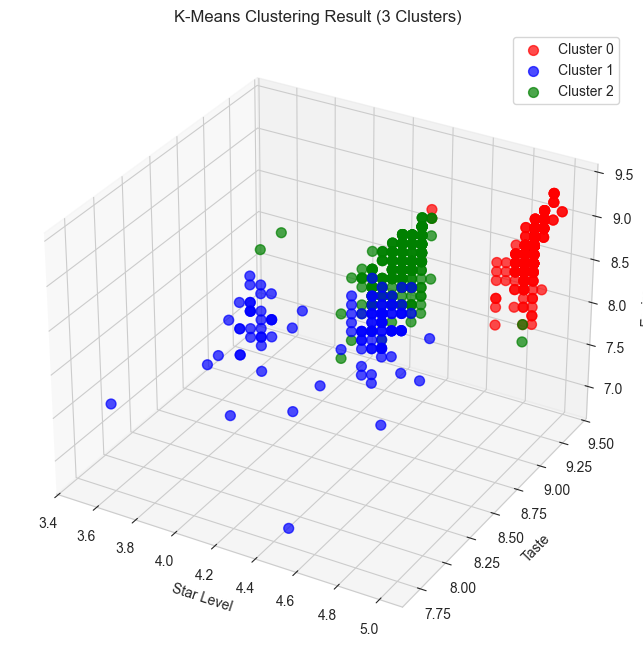


Cluster Sample Counts:
cluster
0    357
1    115
2    277
Name: count, dtype: int64

Cluster Average Scores:
         star_num  taste  environment  services
cluster                                        
0            5.00   9.06         9.00      9.05
1            4.34   8.50         8.21      8.20
2            4.50   8.78         8.74      8.73


In [12]:
#K-Means 聚类
# 选取特征并标准化
features = df[['star_num', 'taste', 'environment', 'services']].copy()
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(features_scaled)

# 聚类中心
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
print("Clustering Centers (Original Scale):")
print(pd.DataFrame(cluster_centers, columns=['star_num', 'taste', 'environment', 'services']))

# 3D 散点图
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
colors = ['red', 'blue', 'green']
for cluster_id in range(3):
    subset = df[df['cluster'] == cluster_id]
    ax.scatter(subset['star_num'], subset['taste'], subset['environment'],
               c=colors[cluster_id], label=f'Cluster {cluster_id}', s=50, alpha=0.7)

ax.set_xlabel('Star Level')
ax.set_ylabel('Taste')
ax.set_zlabel('Environment')
ax.set_title('K-Means Clustering Result (3 Clusters)')
ax.legend()
plt.show()

# 类别统计
print("\nCluster Sample Counts:")
print(df['cluster'].value_counts().sort_index())
print("\nCluster Average Scores:")
print(df.groupby('cluster')[['star_num', 'taste', 'environment', 'services']].mean().round(2))

In [ ]:
#智能推荐系统
def recommend_hotpot(df, min_star=4.0, price_min=0, price_max=500,
                     min_taste=8.0, min_env=8.0, min_serv=8.0, keyword=''):
    mask = (df['star_num'] >= min_star) & \
           (df['avg_price'] >= price_min) & (df['avg_price'] <= price_max) & \
           (df['taste'] >= min_taste) & (df['environment'] >= min_env) & \
           (df['services'] >= min_serv)
    result = df[mask].copy()
    if keyword:
        result = result[result['recommend'].str.contains(keyword, na=False)]
    result['综合评分'] = (result['taste'] + result['environment'] + result['services']) / 3
    result = result.sort_values(['综合评分', 'comment'], ascending=[False, False])
    return result[['name', 'star', 'avg_price', 'taste', 'environment', 'services', 'comment', 'recommend', '综合评分']]
from IPython.display import display

print("=" * 50)
print("智能火锅推荐系统")
print("直接回车使用系统默认值（星级≥4.5，价格0-500，评分≥8.5）")
print("=" * 50)

min_star = float(input("最低星级：") or 4.5)
price_min = float(input("最低人均价格：") or 0)
price_max = float(input("最高人均价格：") or 500)
min_taste = float(input("最低口味评分：") or 8.5)
min_env = float(input("最低环境评分：") or 8.5)
min_serv = float(input("最低服务评分：") or 8.5)
keyword = input("想吃的关键词（如 毛肚，不填则跳过）：")

print("\n⏳ 正在筛选...")

recommended = recommend_hotpot(df, min_star, price_min, price_max,
                               min_taste, min_env, min_serv, keyword)

total_count = len(recommended)
print(f"\n✅ 符合条件的火锅店共 {total_count} 家")

if total_count == 0:
    print("没有找到符合的店铺，请放宽条件重试。")
else:
    print("\n📋 全部结果如下：\n")
    display(recommended)   # 直接显示全部

智能火锅推荐系统
直接回车使用系统默认值（星级≥4.5，价格0-500，评分≥8.5）
